# Notebook 02: Baseline Autoencoder Model

## Project 19 - Anomaly Detection Using Autoencoders

**Pipeline stage:** 3 of 5 - Baseline Model Training

### Purpose

This notebook trains a baseline fully connected autoencoder on the processed KDD Cup 1999 training data produced by `01_data_preprocessing.ipynb`, and evaluates its ability to detect anomalous (attack) network traffic using a reconstruction-error threshold. The goal is to establish a reference performance level before the systematic hyperparameter search carried out in `03_hyperparameter_optimization.ipynb`.

### Methodology

The autoencoder architecture is implemented in `src/model.py` using the Keras functional API and consists of a symmetric encoder-decoder pair of fully connected layers with a low-dimensional latent bottleneck. The network is trained to minimize the mean squared reconstruction error between its input and output using the Adam optimizer.

Because the model is trained **exclusively on normal traffic**, it learns a compressed representation that reconstructs normal patterns accurately. At evaluation time, a sample is classified as an **anomaly** if its reconstruction error exceeds a threshold calibrated at a chosen percentile (e.g., the 95th percentile) of the training-set error distribution; samples the model reconstructs poorly are, by construction, dissimilar from normal traffic and are therefore flagged as potential attacks.

### Steps

1. Load the processed training and test arrays.
2. Define and instantiate the baseline autoencoder architecture.
3. Train the model using the shared `train_autoencoder` helper and save it to `models/`.
4. Calibrate the anomaly threshold on the training reconstruction errors and compute classification metrics on the test set.

In [ ]:
# Public Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import sys

# Custom Imports
src_dir = Path("../src")
sys.path.insert(0, str(src_dir))

from data_preprocessing import load_data, resolve_project_root
from evaluate import calculate_reconstruction_error, generate_anomaly_metrics_and_threshold
from train import save_model, set_global_seed, train_autoencoder

project_root = resolve_project_root()

# Set seed for reproducibility
set_global_seed(42)

# Create models directory if it doesn't exist
models_dir = project_root / "models"
data_dir = project_root / "data" / "processed"

## 1. Load Training and Test Data

Load the training and test tables produced by `01_data_preprocessing.ipynb` and split each into a feature matrix and a numeric binary label vector (`0` = normal, `1` = anomaly).

In [12]:
# Load train and test tables
train_data_path = data_dir / "train.csv"
test_data_path = data_dir / "test.csv"

train_set = load_data(train_data_path)
test_set = load_data(test_data_path)

print("Train Set:")
display(train_set.head())
print("Test Set:")
display(test_set.head())

# Convert labels to numeric classes expected by sklearn metrics
label_to_int = {"normal": 0, "anomaly": 1}

feature_cols = [c for c in train_set.columns if c not in ["label", "binary_label"]]
X_train_df = train_set[feature_cols]
X_test_df = test_set[feature_cols]

y_train_series = train_set["binary_label"].map(label_to_int)
y_test_series = test_set["binary_label"].map(label_to_int)

if y_train_series.isna().any() or y_test_series.isna().any():
    raise ValueError("Unexpected values found in binary_label. Expected only 'normal' and 'anomaly'.")

# Default source: arrays built from CSV
X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)
y_train = y_train_series.to_numpy(dtype=np.int32)
y_test = y_test_series.to_numpy(dtype=np.int32)
source = "CSV-derived arrays"

print(f"Train Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Test Set Shape: {X_test.shape}, Labels Shape: {y_test.shape}")

Train Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.026526,-0.092098,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
1,-0.145561,-0.026472,-0.051431,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
2,-0.145561,-0.026689,-0.086207,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
3,-0.145561,-0.026173,-0.066131,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.025901,0.015446,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False


Test Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
1,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
2,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,True,False,False,False,False,False,False,False,False,False
3,-0.145561,-0.029163,-0.080533,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False


Train Set Shape: (61482, 118), Labels Shape: (61482,)
Test Set Shape: (84104, 118), Labels Shape: (84104,)


## 2. Model Architecture

The autoencoder architecture is defined once in `src/model.py` (`build_autoencoder`) and reused across every notebook in this project, ensuring that the baseline model, the hyperparameter-search candidates, and the final evaluated models are all built from the same, tested implementation. The architecture is a symmetric encoder-decoder stack of dense layers with a configurable latent bottleneck, trained to reconstruct its own input.

## 3. Train the Baseline Autoencoder

The model is trained using `train_autoencoder` from `src/train.py`, which centralizes seeding, device selection (GPU/MPS/CPU), model construction, compilation, and the `model.fit` call so that training behavior stays consistent across every notebook that trains a model. The trained model is then saved to `models/autoencoder_baseline_model.keras`.

In [13]:
# Train the model using the shared training helper so seeding and device selection stay centralized.
model, history = train_autoencoder(
    X_train,
    input_dim=X_train.shape[1],
    latent_dim=128,
    epochs=50,
    batch_size=256,
    learning_rate=0.1,
    )

# Save the model
print("Saving the model...")
save_model(model, models_dir / "autoencoder_baseline_model.keras")
print("Final model saved!")

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - loss: 0.3018
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - loss: 0.2874
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - loss: 0.2874
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 0.2875
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - loss: 0.2875
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - loss: 0.2875
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - loss: 0.2875
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - loss: 0.2875
Epoch 9/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - loss: 0.2875
Epoch 10/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - loss: 0.2875
Epoch 11/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.2875
Epoch 12/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - loss: 0.2875
Epoch 13/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - loss: 0.2875
Epoch 14/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - loss: 0.2875
Epoch 15/50
241/241 ━━━━━━━━━

## 4. Anomaly Thresholding and Baseline Evaluation

With the baseline model trained (or reloaded from disk if this cell is run independently), the reconstruction-error threshold is calibrated on the training set and applied to the test set to produce binary anomaly predictions. Accuracy, precision, recall, and F1-score are then reported to establish the baseline performance that the hyperparameter search in `03_hyperparameter_optimization.ipynb` aims to improve upon.

In [ ]:
# Reconstruction-error threshold used to flag anomalies
THRESHOLD_PERCENTILE = 95

A new final model has been trained in the notebook.


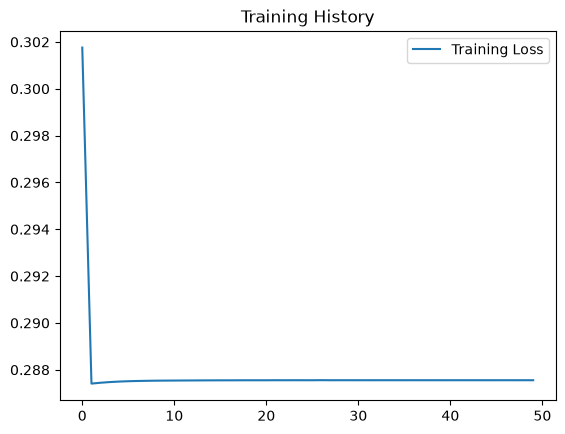


Final Model Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 128)            │         8,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 118)            │         8,022 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,164 (188.14 KB)

 Trainable params: 16,054 (62.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,110 (125.43 KB)

Generating anomaly metrics and threshold...

Accuracy: 0.9500
Precision: 0.9772
Recall: 0.9493
F1-score: 0.9630


In [15]:
# Check if the final model has been trained in the notebook; otherwise load it from disk
if "model" not in locals() or model is None:
    print("Final model not found. Loading the best model from model directory...")
    model = keras.models.load_model(project_root / "models" / "autoencoder_baseline_model.keras")
else:
    print("A new final model has been trained in the notebook.")

# Plot available training history safely (if present)
if "history" in locals() and hasattr(history, "history"):
    if "loss" in history.history:
        plt.plot(history.history["loss"], label="Training Loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Training History")
    plt.legend()
    plt.show()

# Output the model summary for verification
print("\nFinal Model Summary:")
model.summary()

print("Generating anomaly metrics and threshold...\n")
threshold, y_pred, metrics = generate_anomaly_metrics_and_threshold(
    model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE
)
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1-score: {metrics['f1_score']:.4f}")